<img src="../resources/HTLstp-RGB150.png" alt="HTL" width=200>
REFR - Prof. Franz Reichel

DSAI - 4XHIF Klasse

---

# Visualisierung von:
* Mean (Durchschnitt)
* Median (Mittlerer Wert der sortierten Daten)
* Mode (Häufigster Wert)
* Variance (Wie stark Werte um den Mittelwert schwanken)
* Standard Deviation (Quadratwurzel der Varianz, praktische Streuungsangabe)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import (norm)

## Normalverteilung - Visualisierung

## Lognormalverteilung - Visualisierung

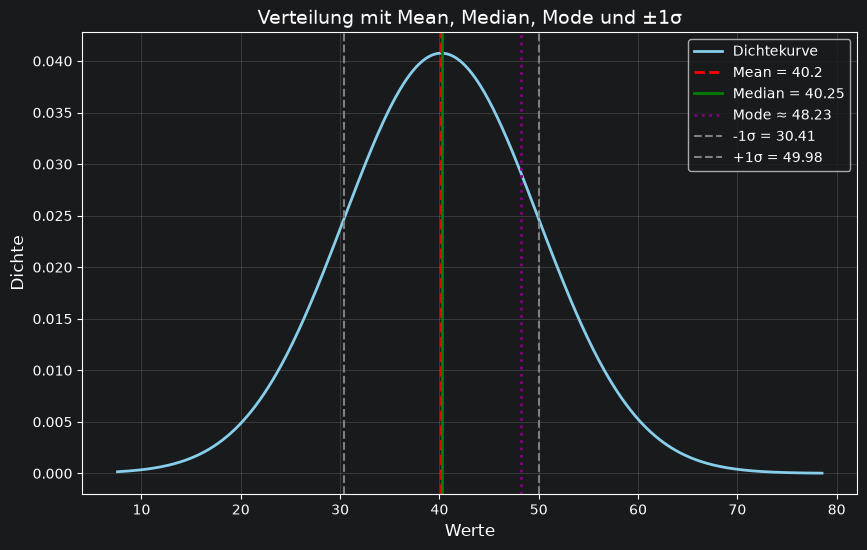

In [2]:
# Zufallsdaten erzeugen (normalverteilte Daten)
np.random.seed(42)
data = np.random.normal(loc=40, scale=10, size=1000)

# Statistische Werte berechnen
mean_n = np.mean(data)
median_n = np.median(data)
mode_n = data[np.argmax(np.bincount(data.astype(int)))]
std_dev_n = np.std(data)

# Bereich für die Kurve
x_n = np.linspace(min(data), max(data), 500)
y_n = norm.pdf(x_n, mean_n, std_dev_n) * 1

# Plot erstellen (Liniendiagramm statt Histogramm)
plt.figure(figsize=(10,6))
plt.plot(x_n, y_n, color="skyblue", linewidth=2, label="Dichtekurve")


# Mean, Median, Mode markieren
plt.axvline(mean_n, color='red', linestyle='--', linewidth=2, label=f"Mean = {mean_n:.1f}")
plt.axvline(median_n, color='green', linestyle='-', linewidth=2, label=f"Median = {median_n:.2f}")
plt.axvline(mode_n, color='purple', linestyle=':', linewidth=2, label=f"Mode ≈ {mode_n:.2f}")


# Standardabweichung (±1σ) markieren
plt.axvline(mean_n - std_dev_n, color='gray', linestyle='--', linewidth=1.5, label=f"-1σ = {mean_n-std_dev_n:.2f}")
plt.axvline(mean_n + std_dev_n, color='gray', linestyle='--', linewidth=1.5, label=f"+1σ = {mean_n+std_dev_n:.2f}")

# Beschriftungen und Layout
plt.title("Verteilung mit Mean, Median, Mode und ±1σ", fontsize=14)
plt.xlabel("Werte", fontsize=12)
plt.ylabel("Dichte", fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

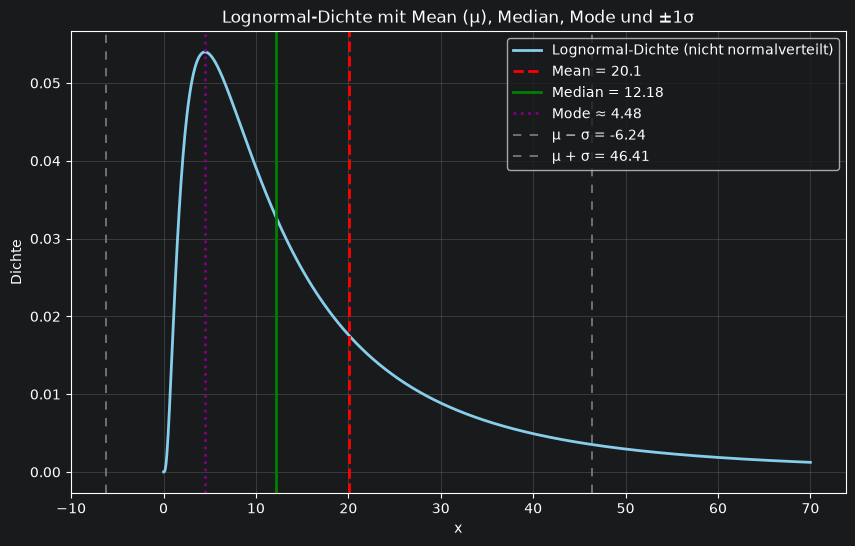

In [3]:
# Parameter der Lognormalverteilung
mu = 2.5      # Mittelwert des zugrunde liegenden Normal-Logs
sigma = 1   # Standardabweichung des zugrunde liegenden Normal-Logs

# x-Werte (nur positive Werte sinnvoll)
x_l = np.linspace(0.01, 70, 1000)

# Wahrscheinlichkeitsdichtefunktion (PDF) der Lognormalverteilung
y_l = (1 / (x_l * sigma * np.sqrt(2 * np.pi))) * np.exp(- (np.log(x_l) - mu)**2 / (2 * sigma**2))

# Kenngrößen berechnen
mean_l = np.exp(mu + sigma**2 / 2)
median_l = np.exp(mu)
mode_l = np.exp(mu - sigma**2)
variance_l = (np.exp(sigma**2) - 1) * np.exp(2*mu + sigma**2)
std_dev_l = np.sqrt(variance_l)

# Intervalle für ±1σ
mean_minus_l = mean_l - std_dev_l
mean_plus_l = mean_l + std_dev_l

# Plot
plt.figure(figsize=(10,6))
plt.plot(x_l, y_l, color="skyblue", linewidth=2, label="Lognormal-Dichte (nicht normalverteilt)")

# Vertikale Linien für Mean, Median, Mode
# Mean, Median, Mode markieren
plt.axvline(mean_l, color='red', linestyle='--', linewidth=2, label=f"Mean = {mean_l:.1f}")
plt.axvline(median_l, color='green', linestyle='-', linewidth=2, label=f"Median = {median_l:.2f}")
plt.axvline(mode_l, color='purple', linestyle=':', linewidth=2, label=f"Mode ≈ {mode_l:.2f}")

# Vertikale Linien für ±1σ
plt.axvline(mean_minus_l, color='gray', linestyle=(0, (5, 5)), linewidth=1.2, label=f"μ − σ = {mean_minus_l:.2f}")
plt.axvline(mean_plus_l, color='gray', linestyle=(0, (5, 5)), linewidth=1.2, label=f"μ + σ = {mean_plus_l:.2f}")

# Diagramm verschönern
plt.title("Lognormal-Dichte mit Mean (μ), Median, Mode und ±1σ")
plt.xlabel("x")
plt.ylabel("Dichte")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

$[
f(x; \mu, \sigma) = \frac{1}{x \, \sigma \sqrt{2 \pi}}
\exp\left(-\frac{(\ln(x) - \mu)^2}{2\sigma^2}\right), \quad x > 0
]$